<a href="https://colab.research.google.com/github/dream001871-cell/anan.github.io/blob/main/harvard-nlp/annotated-transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **模型架构**

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import math, copy, time
from torch.autograd import Variable
import matplotlib.pyplot as plt
import seaborn
seaborn.set_context(context="talk")
%matplotlib inline

Transformer 模型最核心的编码器 - 解码器（Encoder-Decoder）架构基类，是整个 Transformer 模型的骨架。遵循 PyTorch 的nn.Module规范，封装了编码器、解码器、嵌入层和生成器的协作逻辑

In [ ]:
class EncoderDecoder(nn.Module):
  def __init__(self, encoder, decoder, src_embed, tgt_embed, generator):
    super(EncoderDecoder, self).__init__()
    self.encoder = encoder
    self.decoder = decoder
    self.src_embed = src_embed
    self.tgt_embed = tgt_embed
    self.generator = generator

  def forward(self, src, tgt, src_mask, tgt_mask):
    return self.decode(self.encode(src, src_mask), src_mask,
                        tgt, tgt_mask)
  def encode(self, src, src_mask):
    return self.encoder(self.src_embed(src), src_mask)

  def decode(self, memory, src_mask, tgt, tgt_mask):
    return self.decoder(self.tgt_embed(tgt), memory, src_mask, tgt_mask)

Generator类的核心作用是：将解码器输出的高维语义向量（维度为d_model）映射到目标词汇表的维度，并通过log_softmax输出每个词汇的对数概率，为后续计算损失（如负对数似然损失）或生成最终预测结果提供基础。

In [ ]:
class Generator(nn.Module):
  def __init__(self, d_model, vocab):
    super(Generator, self).__init__()
    self.proj = nn.Linear(d_model, vocab)
  def forward(self, x):
    return F.log_softmax(self.proj(x), dim=-1)

Transformer 遵循这种整体架构，编码器和解码器分别采用堆叠式自注意力层和逐点全连接层，如图 1 的左半部分和右半部分所示。

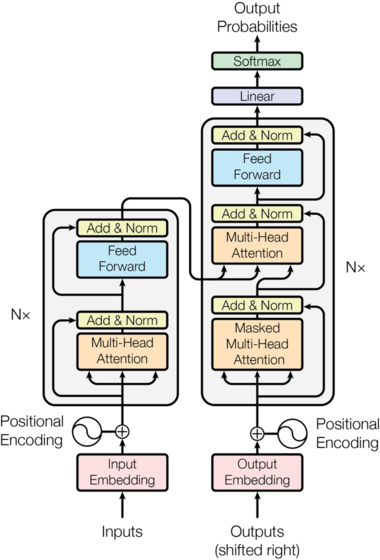

# **编码器和解码器协议栈**

## 编码器


clones：工具函数，深度复制指定的神经网络模块 N 次，返回可管理的模块列表，是 Transformer 堆叠多层的核心工具。

Encoder：Transformer 的编码器类，将 N 个相同的编码器层堆叠，输入依次经过所有层后做层归一化，输出最终的源序列语义表示（memory）。


In [ ]:
def clones(module, N):
    return nn.ModuleList([copy.deepcopy(module) for _ in range(N)])

In [ ]:
class Encoder(nn.Module):
    def __init__(self, layer, N):
        super(Encoder, self).__init__()
        self.layers = clones(layer, N)
        self.norm = LayerNorm(layer.size)
    def forward(self, x, mask):
        for layer in self.layers:
            x = layer(x, mask)
        return self.norm(x)

在两个子层之间 采用残差连接 ，然后进行层归一化。

In [ ]:
class LayerNorm(nn.Module):
    def __init__(self, features, eps=1e-6):
        super(LayerNorm, self).__init__()
        self.a_2 = nn.Parameter(torch.ones(features))
        self.b_2 = nn.Parameter(torch.zeros(features))
        self.eps = eps

    def forward(self, x):
        mean = x.mean(-1, keepdim=True)
        std = x.std(-1, keepdim=True)
        return self.a_2 * (x - mean) / (std + self.eps) + self.b_2

In [ ]:
class SublayerConnection(nn.Module):
    def __init__(self, size, dropout):
        super(SublayerConnection, self).__init__()
        self.norm = LayerNorm(size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, sublayer):
        return x + self.dropout(sublayer(self.norm(x)))

每一层都有两个子层。第一层是多头自注意力机制，第二层是一个简单的、按位置全连接的前馈网络。

In [ ]:
class EncoderLayer(nn.Module):
    def __init__(self, size, self_attn, feed_forward, dropout):
        super(EncoderLayer, self).__init__()
        self.self_attn = self_attn
        self.feed_forward = feed_forward
        self.sublayer = clones(SublayerConnection(size, dropout), 2)
        self.size = size

    def forward(self, x, mask):
        x = self.sublayer[0](x, lambda x: self.self_attn(x, x, x, mask))
        return self.sublayer[1](x, self.feed_forward)

# **解码器**

解码器也由一个堆栈组成N=6相同的层。

In [ ]:
class Decoder(nn.Module):
    def __init__(self, layer, N):
        super(Decoder, self).__init__()
        self.layers = clones(layer, N)
        self.norm = LayerNorm(layer.size)

    def forward(self, x, memory, src_mask, tgt_mask):
        for layer in self.layers:
            x = layer(x, memory, src_mask, tgt_mask)
        return self.norm(x)

除了每个编码器层中的两个子层之外，解码器还插入了第三个子层，该子层对编码器堆栈的输出执行多头注意力机制。与编码器类似，我们在每个子层周围都使用了残差连接，然后进行层归一化。

In [ ]:
class DecoderLayer(nn.Module):
    def __init__(self, size, self_attn, src_attn, feed_forward, dropout):
        super(DecoderLayer, self).__init__()
        self.size = size
        self.self_attn = self_attn
        self.src_attn = src_attn
        self.feed_forward = feed_forward
        self.sublayer = clones(SublayerConnection(size, dropout), 3)

    def forward(self, x, memory, src_mask, tgt_mask):
        m = memory
        x = self.sublayer[0](x, lambda x: self.self_attn(x, x, x, tgt_mask))
        x = self.sublayer[1](x, lambda x: self.src_attn(x, m, m, src_mask))
        return self.sublayer[2](x, self.feed_forward)

修改了解码器堆栈中的自注意力子层，以防止位置关注后续位置。这种掩蔽，再加上输出嵌入偏移一个位置的事实，确保了位置的预测结果一致。
我
只能依赖于位置小于以下位置的已知输出

In [ ]:
def subsequent_mask(size):
    attn_shape = (1, size, size)
    subsequent_mask = np.triu(np.ones(attn_shape), k=1).astype('uint8')
    return torch.from_numpy(subsequent_mask) == 0

### 注意力掩码下方显示了每个目标词（行）允许关注的位置（列）。在训练期间，单词会被屏蔽，无法关注后续单词。

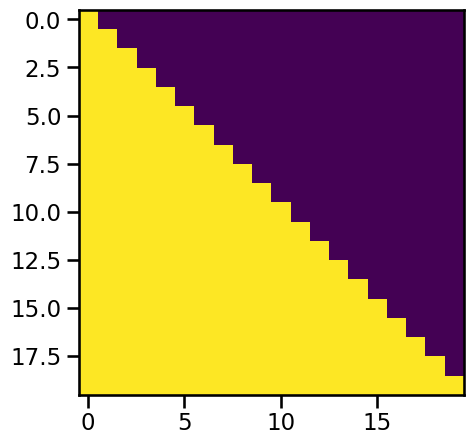

In [ ]:
plt.figure(figsize=(5,5))
plt.imshow(subsequent_mask(20)[0])
None

# 注意力

注意力函数可以描述为将查询和一组键值对映射到输出，其中查询、键、值和输出都是向量。输出计算为值的加权和，每个值的权重由查询与其对应键的兼容性函数计算得出。

我们将这种特殊的注意力机制称为“缩放点积注意力机制”。输入包括查询和维度键。
d
k
以及维度值
d
v
我们计算查询与所有键的点积，并将每个点积除以
√
d
k
并应用 softmax 函数来获得这些值的权重。

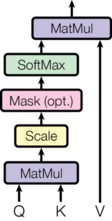

在实践中，我们同时对一组查询计算注意力函数，并将这些查询打包到一个矩阵中。
问
键和值也被打包成矩阵。
K
和
V
我们按如下方式计算输出矩阵：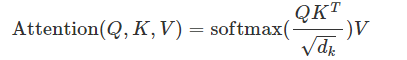

In [ ]:
def attention(query, key, value, mask=None, dropout=None):
    d_k = query.size(-1)
    scores = torch.matmul(query, key.transpose(-2, -1)) / math.sqrt(d_k)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, -1e9)
    p_attn = F.softmax(scores, dim=-1)
    if dropout is not None:
        p_attn = dropout(p_attn)
    return torch.matmul(p_attn, value), p_attn

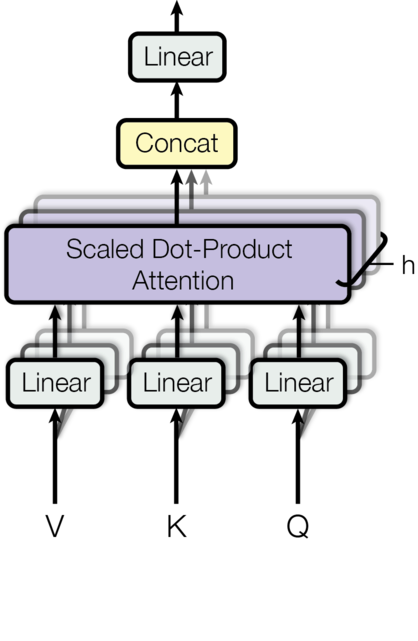

Transformer 中最核心的多头注意力（Multi-Head Attention） 机制，是缩放点积注意力的扩展。其核心思想是：将模型的输入特征拆分为h个独立的注意力头，每个头分别计算缩放点积注意力，最后将所有头的结果拼接并线性变换，从而捕捉序列中不同维度、不同位置的依赖关系，提升模型的表达能力。

In [ ]:
class MultiHeadedAttention(nn.Module):
    def __init__(self, h, d_model, dropout=0.1):
        super(MultiHeadedAttention, self).__init__()
        assert d_model % h == 0
        self.d_k = d_model // h
        self.h = h
        self.linears = clones(nn.Linear(d_model, d_model), 4)
        self.attn = None
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, query, key, value, mask=None):
        if mask is not None:
            mask = mask.unsqueeze(1)
        nbatches = query.size(0)
        query, key, value = [
            l(x).view(nbatches, -1, self.h, self.d_k).transpose(1, 2)
            for l, x in zip(self.linears, (query, key, value))
        ]
        x, self.attn = attention(query, key, value, mask=mask, dropout=self.dropout)
        x = x.transpose(1, 2).contiguous().view(nbatches, -1, self.h * self.d_k)
        return self.linears[-1](x)

## 注意力机制在我们模型中的应用

Transformer模型以三种不同的方式使用多头注意力机制：1）在“编码器-解码器注意力”层中，查询来自前一个解码器层，记忆键和值来自编码器的输出。这使得解码器中的每个位置都能关注输入序列中的所有位置。这模拟了序列到序列模型（例如 [参考文献] [链接文字](https://arxiv.org/abs/1609.08144)）中典型的编码器-解码器注意力机制。

2) 编码器包含自注意力层。在自注意力层中，所有键、值和查询都来自同一位置，在本例中，即编码器前一层的输出。编码器中的每个位置都可以关注其前一层中的所有位置。

3) 类似地，解码器中的自注意力层允许解码器中的每个位置关注到该位置之前的所有位置。我们需要阻止解码器中信息的左向流动，以保持自回归特性。我们在缩放点积注意力机制中实现了这一点，方法是屏蔽掉（设置为−∞
−
∞
 softmax 输入中所有对应于非法连接的值。

# 位置前馈网络

Transformer 中编码器 / 解码器层的位置前馈网络（Positionwise Feed-Forward Network, FFN），是对序列中每个位置的特征独立做非线性变换的组件。其核心公式为：FFN(x)=max(0,xW1​+b1​)W2​+b2​，通过「线性层 + ReLU+Dropout + 线性层」的组合，增强模型的非线性表达能力。

In [ ]:
class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super(PositionwiseFeedForward, self).__init__()
        self.w_1 = nn.Linear(d_model, d_ff)
        self.w_2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.w_2(self.dropout(F.relu(self.w_1(x))))

# 嵌入和 Softmax

Transformer 中的词嵌入层（Embeddings），核心作用是将离散的词汇 ID 转换为连续的高维向量（词嵌入），并通过乘以√d_model缩放嵌入向量的幅度，适配后续注意力机制的计算尺度。

In [ ]:
class Embeddings(nn.Module):
    def __init__(self, d_model, vocab):
        super(Embeddings, self).__init__()
        self.lut = nn.Embedding(vocab, d_model)
        self.d_model = d_model

    def forward(self, x):
        return self.lut(x) * math.sqrt(self.d_model)

# 位置编码

 Transformer 中的位置编码（Positional Encoding） 模块，核心作用是：为序列中的每个位置添加唯一的位置信息（因为 Transformer 的自注意力层本身不包含位置感知能力），通过正弦 / 余弦函数生成固定的位置编码向量，叠加到词嵌入向量上，让模型能捕捉序列的顺序特征。

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * -(math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + Variable(self.pe[:, :x.size(1)], requires_grad=False)
        return self.dropout(x)

在位置编码下方，会根据位置添加一个正弦波。每个维度的波形频率和偏移量都不同。

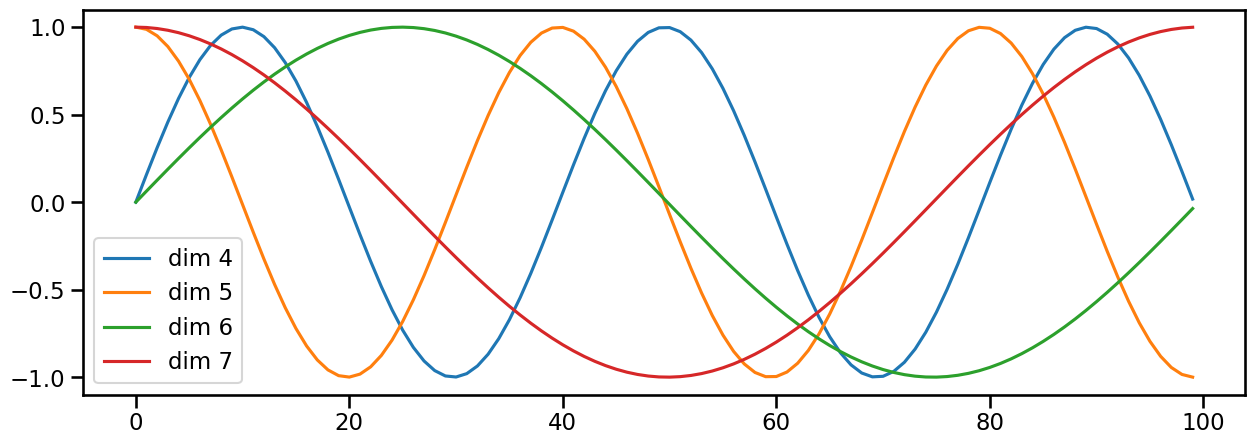

In [ ]:
plt.figure(figsize=(15, 5))
pe = PositionalEncoding(20, 0)
y = pe.forward(Variable(torch.zeros(1, 100, 20)))
plt.plot(np.arange(100), y[0, :, 4:8].data.numpy())
plt.legend(["dim %d"%p for p in [4,5,6,7]])
None

# 整个模型

Transformer 模型的核心工具函数，作用是：根据传入的超参数（词汇表大小、层数、模型维度等），自动组装 Transformer 的所有组件（编码器、解码器、嵌入层、位置编码、注意力层、前馈网络等），并初始化模型参数，最终返回一个完整的 Encoder-Decoder 架构的 Transformer 模型。

In [ ]:
def make_model(src_vocab, tgt_vocab, N=6,
               d_model=512, d_ff=2048, h=8, dropout=0.1):
    """
    Transformer模型构建工具函数：根据超参数自动组装完整的Encoder-Decoder模型
    完全遵循原论文的架构设计（N=6层编码器/解码器，d_model=512等）

    Args:
        src_vocab: 源语言词汇表大小
        tgt_vocab: 目标语言词汇表大小
        N: 编码器/解码器堆叠的层数
        d_model: 模型核心维度
        d_ff: 前馈网络隐藏层维度
        h: 多头注意力的头数
        dropout: Dropout概率

    Returns:
        model: 完整的Transformer模型
    """
    c = copy.deepcopy
    attn = MultiHeadedAttention(h, d_model)
    ff = PositionwiseFeedForward(d_model, d_ff, dropout)
    position = PositionalEncoding(d_model, dropout)
    model = EncoderDecoder(
        Encoder(EncoderLayer(d_model, c(attn), c(ff), dropout), N),
        Decoder(DecoderLayer(d_model, c(attn), c(attn), c(ff), dropout), N),
        nn.Sequential(Embeddings(d_model, src_vocab), c(position)),
        nn.Sequential(Embeddings(d_model, tgt_vocab), c(position)),
        Generator(d_model, tgt_vocab)
    )

    # 初始化模型参数
    for p in model.parameters():
        if p.dim() > 1:
            nn.init.xavier_uniform_(p)
    return model

In [ ]:
tmp_model = make_model(10, 10, 2)
None

# 训练

Transformer 训练过程中用于管理批次数据（Batch） 的类，核心作用是：
封装源序列（src）、目标序列（trg）的原始数据；
自动生成源序列的 padding 掩码、目标序列的「padding + 未来 token 掩码」（防止解码器看到未来内容）；
预处理目标序列（切分为输入和标签）、统计有效 token 数量（用于计算损失）；
是连接数据加载与模型训练的关键桥梁。

In [ ]:
class Batch:
    """
    训练时用于管理批次数据的类，核心功能：
    1. 封装源/目标序列数据
    2. 生成源序列padding掩码、目标序列「padding+未来token」掩码
    3. 切分目标序列为输入（trg）和标签（trg_y），统计有效token数
    """
    def __init__(self, src, trg=None, pad=0):
        """
        初始化批次数据
        Args:
            src: 源序列张量，形状 [batch_size, src_seq_len]（词汇ID）
            trg: 目标序列张量（可选），形状 [batch_size, trg_seq_len]；推理时可不传
            pad: padding的标记ID（默认0），用于区分有效token和padding
        """
        self.src = src  # 保存源序列原始数据
        # -------------------------- 生成源序列掩码（src_mask） --------------------------
        # 1. src != pad → [batch_size, src_seq_len]：True表示有效token，False表示padding
        # 2. unsqueeze(-2) → [batch_size, 1, src_seq_len]：扩展维度，适配多头注意力的维度要求
        # 作用：屏蔽源序列中的padding token，避免模型关注无效内容
        self.src_mask = (src != pad).unsqueeze(-2)

        # 如果传入了目标序列（训练阶段），则处理目标序列相关数据
        if trg is not None:
            # -------------------------- 切分目标序列为输入和标签 --------------------------
            # self.trg：目标序列输入（喂给解码器），去掉最后一个token → [batch_size, trg_seq_len-1]
            # 例如：trg = [1,2,3,4] → self.trg = [1,2,3]
            self.trg = trg[:, :-1]
            # self.trg_y：目标序列标签（计算损失），去掉第一个token → [batch_size, trg_seq_len-1]
            # 例如：trg = [1,2,3,4] → self.trg_y = [2,3,4]
            # 核心逻辑：解码器输入第i个token，预测第i+1个token
            self.trg_y = trg[:, 1:]

            # -------------------------- 生成目标序列掩码（trg_mask） --------------------------
            # 掩码包含两部分：padding掩码（屏蔽padding） + 未来token掩码（屏蔽未来内容）
            self.trg_mask = self.make_std_mask(self.trg, pad)

            # -------------------------- 统计有效token数量 --------------------------
            # (self.trg_y != pad) → 标记有效token位置；sum() → 统计批次内所有有效token数
            # 用于后续计算平均损失（总损失 / 有效token数），避免padding影响损失计算
            self.ntokens = (self.trg_y != pad).data.sum()

    @staticmethod
    def make_std_mask(tgt, pad):
        """
        生成目标序列的标准掩码：同时屏蔽padding和未来的token
        Args:
            tgt: 目标序列输入（self.trg），形状 [batch_size, trg_seq_len-1]
            pad: padding的标记ID

        Returns:
            tgt_mask: 目标序列掩码，形状 [batch_size, 1, trg_seq_len-1, trg_seq_len-1]
        """
        # 第一步：生成padding掩码 → [batch_size, 1, trg_seq_len-1]
        # 作用：屏蔽padding token
        tgt_mask = (tgt != pad).unsqueeze(-2)

        # 第二步：生成未来token掩码（subsequent_mask），并与padding掩码叠加
        # 1. subsequent_mask(tgt.size(-1)) → 生成下三角掩码 [1, trg_seq_len-1, trg_seq_len-1]
        #    下三角为True（可见），上三角为False（屏蔽未来token）
        # 2. type_as(tgt_mask.data) → 转换为与tgt_mask相同的数据类型/设备
        # 3. & → 按位与：同时满足「不是padding」且「不是未来token」的位置才为True
        tgt_mask = tgt_mask & Variable(
            subsequent_mask(tgt.size(-1)).type_as(tgt_mask.data)
        )
        return tgt_mask

# 补充：subsequent_mask函数（原代码中依赖的未来token掩码生成函数）
def subsequent_mask(size):
    """生成后续token掩码，屏蔽未来的位置"""
    attn_shape = (1, size, size)
    # 生成上三角矩阵（对角线及以下为0，以上为1），取反后下三角为1（可见）
    subsequent_mask = torch.triu(torch.ones(attn_shape), diagonal=1).type(torch.uint8)
    return subsequent_mask == 0

Transformer训练 / 验证的核心循环函数，作用是：
遍历一个 epoch 的批次数据，依次将数据输入模型进行前向传播；
计算每个批次的损失（按有效 token 归一化），累计总损失和总 token 数；
定期打印训练日志（步数、损失、token 处理速度），监控训练进度；
最终返回整个 epoch 的「平均损失 per token」，用于评估训练效果。

In [ ]:
import time  # 需导入time模块（原代码依赖但未显式写出）

def run_epoch(data_iter, model, loss_compute):
    """
    Transformer单轮epoch的训练/验证循环
    核心逻辑：遍历批次数据→模型前向传播→计算损失→累计统计→打印日志→返回平均损失

    Args:
        data_iter: 数据迭代器，每次返回一个Batch类实例（包含src/trg/mask/ntokens等）
        model: 训练的Transformer模型（EncoderDecoder类实例）
        loss_compute: 损失计算对象/函数，负责将模型输出转换为损失值（封装了损失函数、优化器等）

    Returns:
        float: 整个epoch的平均损失（总损失 / 总有效token数）
    """
    # 记录epoch开始时间，用于计算token处理速度
    start = time.time()
    # 累计整个epoch的总损失（未归一化）
    total_loss = 0
    # 累计整个epoch的有效token总数（用于计算平均损失）
    total_tokens = 0
    # 临时累计token数（用于每50步打印日志时计算速度）
    tokens = 0

    # 遍历数据迭代器，i为批次索引，batch为Batch类实例
    for i, batch in enumerate(data_iter):
        # -------------------------- 1. 模型前向传播 --------------------------
        # 输入：源序列、解码器输入、源掩码、目标掩码
        # 输出：模型预测的对数概率（形状 [batch_size, trg_seq_len-1, tgt_vocab]）
        out = model.forward(batch.src, batch.trg, batch.src_mask, batch.trg_mask)

        # -------------------------- 2. 计算批次损失 --------------------------
        # loss_compute：封装了损失计算逻辑（如log_softmax + NLLLoss），并可能包含反向传播/优化
        # 参数：模型输出out、目标标签trg_y、该批次有效token数ntokens
        # 返回：该批次的总损失（已按ntokens归一化或未归一化，取决于loss_compute实现）
        loss = loss_compute(out, batch.trg_y, batch.ntokens)

        # -------------------------- 3. 累计统计 --------------------------
        total_loss += loss          # 累计总损失
        total_tokens += batch.ntokens  # 累计总有效token数
        tokens += batch.ntokens     # 临时累计token数（用于日志）

        # -------------------------- 4. 定期打印训练日志 --------------------------
        # 每50个批次打印一次日志（i%50==1：第1、51、101...步打印）
        if i % 50 == 1:
            # 计算从上次打印到当前的耗时
            elapsed = time.time() - start
            # 打印日志：批次步数、该批次平均损失（损失/有效token数）、token处理速度（token/秒）
            print(
                "Epoch Step: %d Loss: %f Tokens per Sec: %f" %
                (i, loss / batch.ntokens, tokens / elapsed)
            )
            # 重置开始时间和临时token数，用于下一个50步的统计
            start = time.time()
            tokens = 0

    # -------------------------- 5. 返回整个epoch的平均损失 --------------------------
    # 总损失 / 总有效token数 → 平均每个token的损失，便于不同epoch间对比
    return total_loss / total_tokens

# 训练数据和批处理


Transformer 数据加载时的动态批次大小计算函数（batch_size_fn），核心作用是：
在按批次打包数据时，不是简单按「样本数量」划分批次，而是按「序列总 token 数（含 padding）」动态控制批次大小，保证每个批次的总 token 数不超过阈值（避免显存溢出）。
函数会跟踪批次中最长的源序列 / 目标序列长度，计算当前批次的总 token 数（样本数 × 最长序列长度），作为批次大小的判断依据。

In [ ]:
# 定义全局变量，用于跟踪当前批次中最长的源/目标序列长度
# max_src_in_batch：当前批次中源序列的最大长度
# max_tgt_in_batch：当前批次中目标序列的最大长度（含额外padding）
global max_src_in_batch, max_tgt_in_batch

def batch_size_fn(new, count, sofar):
    """
    动态计算批次大小的函数（适配PyTorch的BucketIterator等数据迭代器）
    核心逻辑：跟踪批次内最长的源/目标序列长度，计算当前批次的总token数（含padding），
    用于判断是否停止向当前批次添加样本（避免显存不足）。

    Args:
        new: 待加入当前批次的新样本（包含src/trg属性，为列表/张量，len(new.src)为序列长度）
        count: 当前批次已包含的样本数量（加入new前的数量）
        sofar: 上一次计算的批次总token数（通常未使用，仅兼容接口）

    Returns:
        int: 当前批次的总token数（源/目标序列的最大总token数）
    """
    # 声明使用全局变量（修改全局变量必须显式声明）
    global max_src_in_batch, max_tgt_in_batch

    # 若当前批次是新批次（count=1，即第一个样本），重置最大长度为0
    if count == 1:
        max_src_in_batch = 0
        max_tgt_in_batch = 0

    # 更新当前批次的源序列最大长度：取现有最大值 vs 新样本的源序列长度
    max_src_in_batch = max(max_src_in_batch, len(new.src))
    # 更新当前批次的目标序列最大长度：取现有最大值 vs 新样本的目标序列长度+2
    # +2的原因：目标序列训练时会切分（trg[:,:-1]作为输入，trg[:,1:]作为标签），
    # 且需额外添加<sos>（开始符）、<eos>（结束符），因此预留2个位置
    max_tgt_in_batch = max(max_tgt_in_batch, len(new.trg) + 2)

    # 计算当前批次源序列的总token数（含padding）：样本数 × 最长源序列长度
    # 例如：3个样本，最长源序列长度10 → 总token数3×10=30（每个样本都padding到10）
    src_elements = count * max_src_in_batch
    # 计算当前批次目标序列的总token数（含padding）：样本数 × 最长目标序列长度
    tgt_elements = count * max_tgt_in_batch

    # 返回源/目标序列中较大的总token数，作为当前批次的有效大小
    # 保证批次的总token数由更长的序列决定，避免其中一个序列类型占满显存
    return max(src_elements, tgt_elements)

# 优化器

Noam 优化器（NoamOpt），核心是封装 PyTorch 原生优化器（如 Adam），并动态调整学习率：
学习率随训练步数先线性上升（预热阶段，warmup），后反比例下降；
学习率与模型维度的平方根成反比，适配 Transformer 的模型尺度；
提供便捷函数get_std_opt，快速生成符合原论文配置的 Noam 优化器。

In [ ]:
import torch

class NoamOpt:
    """
    Transformer专用的Noam优化器：封装Adam优化器，实现动态学习率调度
    学习率公式（原论文）：
        lr = factor × (d_model^(-0.5)) × min(step^(-0.5), step × warmup^(-1.5))
    核心特点：
        1. 预热阶段（step < warmup）：lr ∝ step（线性上升）
        2. 预热后（step ≥ warmup）：lr ∝ 1/√step（反比例下降）
        3. 学习率与模型维度d_model的平方根成反比，适配不同尺度的模型
    """
    def __init__(self, model_size, factor, warmup, optimizer):
        """
        初始化Noam优化器
        Args:
            model_size: 模型核心维度d_model（如512）
            factor: 学习率缩放因子（原论文设为2）
            warmup: 预热步数（原论文设为4000）
            optimizer: PyTorch原生优化器实例（如Adam）
        """
        self.optimizer = optimizer  # 封装的原生优化器（如Adam）
        self._step = 0  # 训练步数计数器（初始为0）
        self.warmup = warmup        # 预热步数
        self.factor = factor        # 学习率缩放因子
        self.model_size = model_size  # 模型维度d_model
        self._rate = 0  # 记录当前学习率（便于查看）

    def step(self):
        """
        执行一次参数更新：
        1. 步数+1
        2. 计算当前学习率并更新到优化器
        3. 调用原生优化器的step()更新参数
        """
        self._step += 1  # 步数自增
        rate = self.rate()  # 计算当前学习率

        # 遍历优化器的参数组，更新学习率
        for p in self.optimizer.param_groups:
            p['lr'] = rate

        self._rate = rate  # 记录当前学习率
        self.optimizer.step()  # 调用原生优化器更新参数

    def rate(self, step = None):
        """
        计算当前步数对应的学习率（核心公式实现）
        Args:
            step: 可选，指定步数；默认使用当前步数self._step
        Returns:
            float: 计算得到的学习率
        """
        if step is None:
            step = self._step

        # 原论文学习率公式拆解：
        # 1. self.model_size ** (-0.5) → d_model^(-0.5)（模型维度缩放项）
        # 2. min(step**(-0.5), step * warmup**(-1.5)) → 步数相关项：
        #    - 预热阶段（step < warmup）：step * warmup^(-1.5) 主导（线性上升）
        #    - 预热后（step ≥ warmup）：step^(-0.5) 主导（反比例下降）
        # 3. self.factor → 整体缩放因子
        return self.factor * (self.model_size ** (-0.5) *
                              min(step ** (-0.5), step * self.warmup ** (-1.5)))

def get_std_opt(model):
    """
    快速生成符合原论文配置的Noam优化器（便捷函数）
    Args:
        model: Transformer模型实例（需包含src_embed[0].d_model属性）
    Returns:
        NoamOpt: 配置好的Noam优化器
    """
    return NoamOpt(
        model_size=model.src_embed[0].d_model,  # 从模型的源嵌入层获取d_model
        factor=2,                              # 原论文缩放因子
        warmup=4000,                           # 原论文预热步数
        # 初始化Adam优化器：
        # - lr=0：初始学习率无意义，由NoamOpt动态调整
        # - betas=(0.9, 0.98)：原论文Adam的β1/β2配置
        # - eps=1e-9：数值稳定性参数
        optimizer=torch.optim.Adam(
            model.parameters(),
            lr=0,
            betas=(0.9, 0.98),
            eps=1e-9
        )
    )

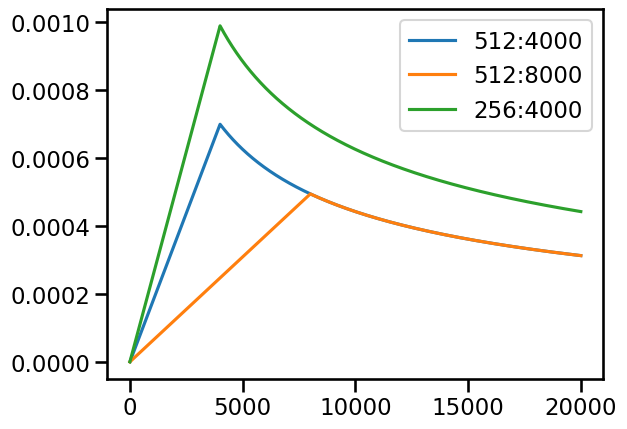

In [ ]:
opts = [NoamOpt(512, 1, 4000, None),
        NoamOpt(512, 1, 8000, None),
        NoamOpt(256, 1, 4000, None)]
plt.plot(np.arange(1, 20000), [[opt.rate(i) for opt in opts] for i in range(1, 20000)])
plt.legend(["512:4000", "512:8000", "256:4000"])
None

# 正则化

标签平滑（Label Smoothing） 技术，核心作用是：
缓解模型对预测标签的过度自信，提升泛化能力；
将硬标签（one-hot）转换为软标签（给正确标签分配高置信度，其余标签均分小概率，padding 位置除外）；
通过 KL 散度损失（KLDivLoss）计算模型预测分布与平滑后标签分布的差异，替代传统的交叉熵损失。

In [ ]:
class LabelSmoothing(nn.Module):
    "Implement label smoothing."
    def __init__(self, size, padding_idx, smoothing=0.0):
        super(LabelSmoothing, self).__init__()
        self.criterion = nn.KLDivLoss(size_average=False)
        self.padding_idx = padding_idx
        self.confidence = 1.0 - smoothing
        self.smoothing = smoothing
        self.size = size
        self.true_dist = None

    def forward(self, x, target):
        assert x.size(1) == self.size
        true_dist = x.data.clone()
        true_dist.fill_(self.smoothing / (self.size - 2))
        true_dist.scatter_(1, target.data.unsqueeze(1), self.confidence)
        true_dist[:, self.padding_idx] = 0
        mask = torch.nonzero(target.data == self.padding_idx)
        if mask.dim() > 0:
            true_dist.index_fill_(0, mask.squeeze(), 0.0)
        self.true_dist = true_dist
        return self.criterion(x, Variable(true_dist, requires_grad=False))

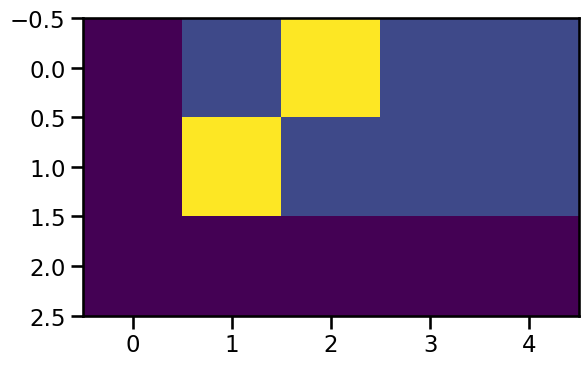

In [ ]:
# Example of label smoothing.
crit = LabelSmoothing(5, 0, 0.4)
predict = torch.FloatTensor([[0, 0.2, 0.7, 0.1, 0],
                             [0, 0.2, 0.7, 0.1, 0],
                             [0, 0.2, 0.7, 0.1, 0]])
v = crit(Variable(predict.log()),
         Variable(torch.LongTensor([2, 1, 0])))

# Show the target distributions expected by the system.
plt.imshow(crit.true_dist)
None

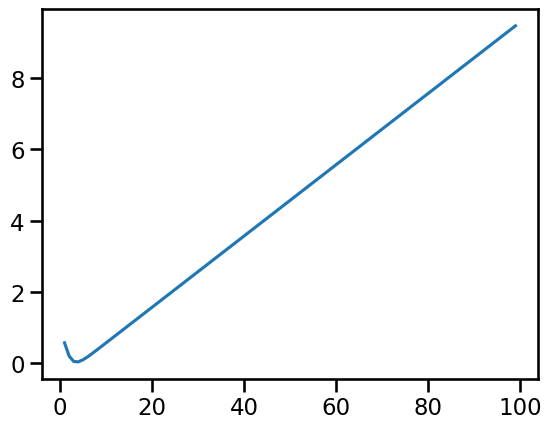

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

crit = LabelSmoothing(5, 0, 0.1)
def loss(x):
    # Create a tensor of logits for 5 classes. Assuming target is class 1.
    logits = torch.FloatTensor([[0.0, x, 0.0, 0.0, 0.0]])
    # Apply log_softmax to these logits to get valid log probabilities
    predict = F.log_softmax(logits, dim=-1)
    return crit(predict, torch.LongTensor([1])).item()

plt.plot(np.arange(1, 100), [loss(x) for x in range(1, 100)])
None

# 第一个例子

## 合成数据

In [ ]:
def data_gen(V, batch, nbatches):
    """
    为「源-目标拷贝任务」生成随机批量数据
    核心逻辑：生成随机整数序列作为源/目标数据，源=目标，方便验证模型拷贝能力

    Args:
        V: 词汇表大小（生成的token ID范围：1~V-1，0为padding）
        batch: 每个批次的样本数量（batch_size）
        nbatches: 要生成的总批次数

    Yields:
        Batch: 每个批次的封装数据（包含src/trg/mask/ntokens等）
    """
    # 循环生成nbatches个批次的数据
    for i in range(nbatches):
        # -------------------------- 1. 生成随机源序列数据 --------------------------
        # np.random.randint(1, V, size=(batch, 10))：
        #   - 1~V-1：避免padding ID（0），保证都是有效token
        #   - size=(batch,10)：每个批次有batch个样本，每个样本序列长度固定为10
        # torch.from_numpy：将numpy数组转换为PyTorch张量
        data = torch.from_numpy(np.random.randint(1, V, size=(batch, 10)))

        # -------------------------- 2. 固定序列第一个token为1 --------------------------
        # data[:, 0] = 1：将所有样本的第一个token设为1（模拟<sos>开始符）
        # 目的：保证每个序列以固定的开始符开头，符合序列任务的格式要求
        data[:, 0] = 1

        # -------------------------- 3. 包装为Variable（兼容旧版PyTorch） --------------------------
        # requires_grad=False：标记为无需计算梯度（数据是输入，不是模型参数）
        # 新版PyTorch可直接用张量，无需Variable包装
        src = Variable(data, requires_grad=False)  # 源序列
        tgt = Variable(data, requires_grad=False)  # 目标序列（与源序列完全相同，拷贝任务）

        # -------------------------- 4. 封装为Batch类并返回 --------------------------
        # pad=0：指定padding的ID为0（生成的data中无0，仅为兼容Batch类接口）
        yield Batch(src, tgt, 0)

## 损失计算

In [ ]:
class SimpleLossCompute:
    """
    简单的损失计算与参数更新类
    核心流程：生成器映射 → 损失计算 → 反向传播 → 优化器更新（可选）
    适配Transformer训练循环，返回批次总损失
    """
    def __init__(self, generator, criterion, opt=None):
        """
        初始化损失计算类
        Args:
            generator: 模型的Generator层（将d_model→词汇表，输出log概率）
            criterion: 损失函数（如LabelSmoothing或NLLLoss）
            opt: 优化器（如NoamOpt，可选；验证时设为None，仅计算损失）
        """
        self.generator = generator  # 生成器层
        self.criterion = criterion  # 损失函数
        self.opt = opt              # 优化器（None时仅计算损失，不更新参数）

    def __call__(self, x, y, norm):
        """
        执行损失计算、反向传播、参数更新
        __call__使实例可像函数一样调用（如loss_compute(out, trg_y, ntokens)）

        Args:
            x: 解码器的输出，形状 [batch_size, trg_seq_len, d_model]
            y: 目标标签，形状 [batch_size, trg_seq_len]（trg_y）
            norm: 归一化因子（该批次的有效token数ntokens）

        Returns:
            float: 该批次的总损失（未归一化，loss×norm）
        """
        # -------------------------- 1. 生成器映射：解码器输出→词汇表log概率 --------------------------
        # x（d_model维度）→ generator → 形状 [batch_size, trg_seq_len, vocab_size] 的log概率
        x = self.generator(x)

        # -------------------------- 2. 计算损失（按有效token数归一化） --------------------------
        # contiguous().view(-1, x.size(-1))：将x展平为 [batch×seq_len, vocab_size]，适配损失函数输入
        # y.contiguous().view(-1)：将y展平为 [batch×seq_len]，作为目标标签
        # / norm：按有效token数归一化损失（避免批次大小/序列长度影响损失）
        loss = self.criterion(
            x.contiguous().view(-1, x.size(-1)),  # 展平后的模型输出
            y.contiguous().view(-1)               # 展平后的目标标签
        ) / norm

        # -------------------------- 3. 反向传播计算梯度 --------------------------
        loss.backward()

        # -------------------------- 4. 优化器更新参数（若传入opt） --------------------------
        if self.opt is not None:
            self.opt.step()          # 更新模型参数（NoamOpt会先调整学习率）
            self.opt.optimizer.zero_grad()  # 清空梯度（避免累积）

        # -------------------------- 5. 返回该批次的总损失 --------------------------
        # loss.data[0]：提取标量损失值（旧版PyTorch写法，新版需用.item()）
        # × norm：还原为批次总损失（因为前面除以了norm）
        return loss.item() * norm

## 贪婪解码

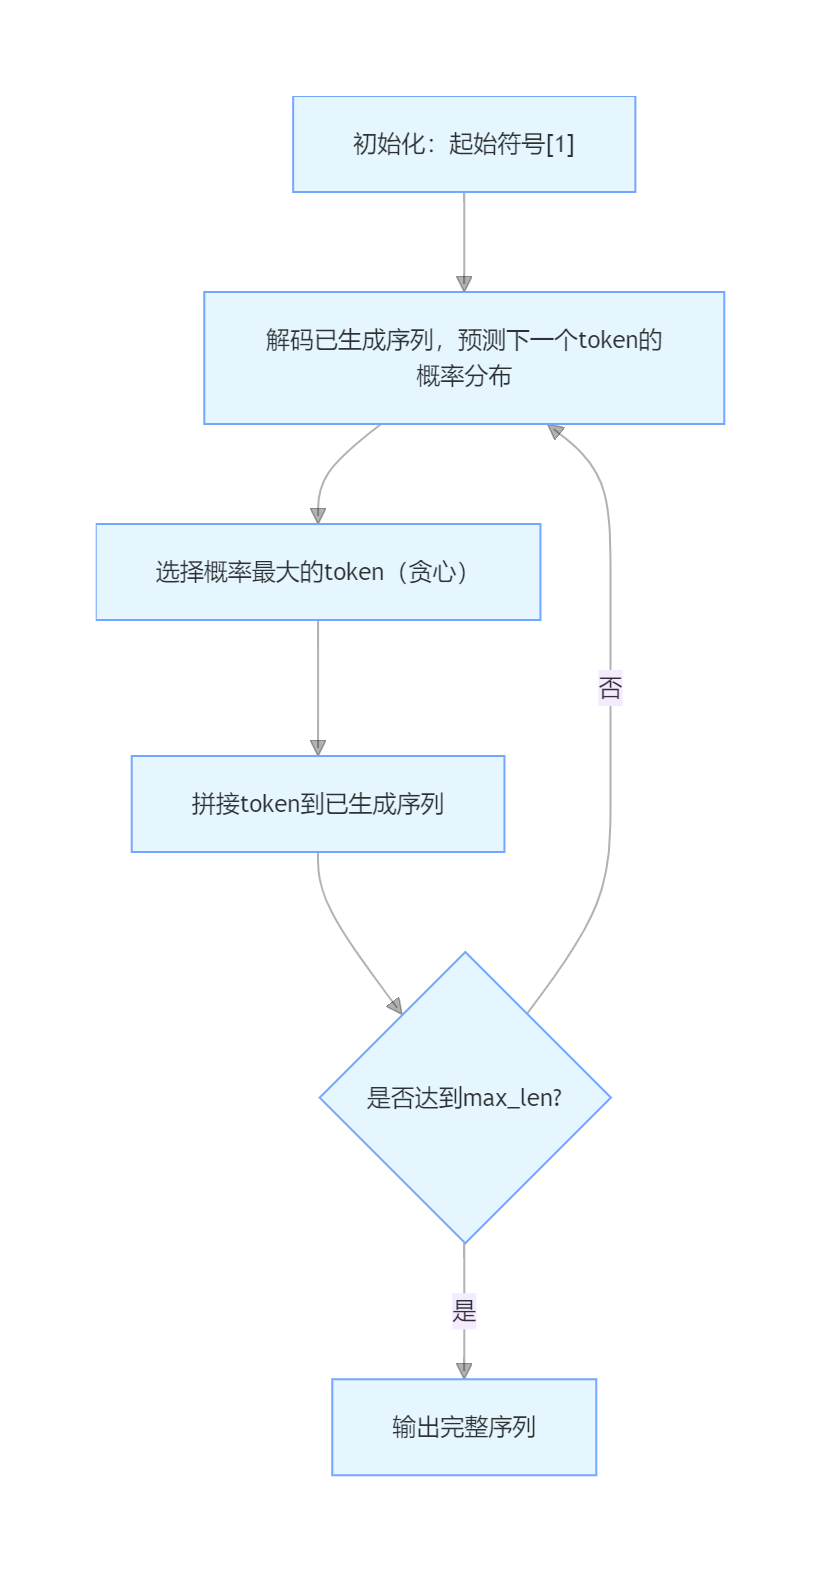

In [ ]:
# Train the simple copy task.
V = 11
criterion = LabelSmoothing(size=V, padding_idx=0, smoothing=0.0)
model = make_model(V, V, N=2)
model_opt = NoamOpt(model.src_embed[0].d_model, 1, 400,
        torch.optim.Adam(model.parameters(), lr=0, betas=(0.9, 0.98), eps=1e-9))

for epoch in range(10):
    model.train()
    run_epoch(data_gen(V, 30, 20), model,
              SimpleLossCompute(model.generator, criterion, model_opt))
    model.eval()
    print(run_epoch(data_gen(V, 30, 5), model,
                    SimpleLossCompute(model.generator, criterion, None)))

Epoch Step: 1 Loss: 2.884006 Tokens per Sec: 423.409760
Epoch Step: 1 Loss: 1.882349 Tokens per Sec: 877.153442
tensor(1.8600)
Epoch Step: 1 Loss: 2.034407 Tokens per Sec: 615.637634
Epoch Step: 1 Loss: 1.589852 Tokens per Sec: 826.075317
tensor(1.6147)
Epoch Step: 1 Loss: 1.908817 Tokens per Sec: 624.589233
Epoch Step: 1 Loss: 1.289198 Tokens per Sec: 826.449951
tensor(1.3285)
Epoch Step: 1 Loss: 1.530105 Tokens per Sec: 622.601685
Epoch Step: 1 Loss: 1.171142 Tokens per Sec: 821.763245
tensor(1.1604)
Epoch Step: 1 Loss: 1.680808 Tokens per Sec: 641.804504
Epoch Step: 1 Loss: 1.013736 Tokens per Sec: 624.011536
tensor(1.0767)
Epoch Step: 1 Loss: 1.218247 Tokens per Sec: 461.031219
Epoch Step: 1 Loss: 0.765146 Tokens per Sec: 609.516296
tensor(0.7238)
Epoch Step: 1 Loss: 0.997738 Tokens per Sec: 489.154175
Epoch Step: 1 Loss: 0.408361 Tokens per Sec: 843.289001
tensor(0.3999)
Epoch Step: 1 Loss: 0.605823 Tokens per Sec: 494.666962
Epoch Step: 1 Loss: 0.344550 Tokens per Sec: 840.801819

## 预测

In [ ]:
import torch
from torch.autograd import Variable  # 补充：代码依赖Variable，需导入（注：PyTorch 0.4+后Variable已整合到Tensor）

def greedy_decode(model, src, src_mask, max_len, start_symbol):
    """
    贪心解码函数：Transformer的贪心搜索解码，逐词生成目标序列（复制任务中即原样输出输入序列）
    参数说明：
        model: 训练好的Transformer模型
        src: 源序列输入 (batch_size, seq_len)，此处batch_size=1
        src_mask: 源序列掩码 (batch_size, 1, seq_len)，避免模型关注填充符（此处无填充，全1）
        max_len: 生成序列的最大长度
        start_symbol: 生成序列的起始符号（<bos>），此处设为1
    返回：
        ys: 生成的目标序列 (1, max_len)
    """
    # 1. 编码源序列：将输入src通过编码器得到内存（memory），即编码器的输出
    # memory shape: (batch_size, seq_len, d_model)
    memory = model.encode(src, src_mask)

    # 2. 初始化目标序列：起始时只有一个起始符号(start_symbol)
    # ys初始形状: (1, 1)，值为start_symbol（如1），类型与src一致（LongTensor）
    ys = torch.ones(1, 1).fill_(start_symbol).type_as(src.data)

    # 3. 逐词生成目标序列（直到达到max_len）
    # 循环max_len-1次（因为已初始化1个token）
    for i in range(max_len-1):
        # 3.1 解码：用编码器输出(memory) + 已生成的序列(ys)，预测下一个token
        # subsequent_mask: 生成后续掩码，防止模型看到未来的token（自回归解码核心）
        out = model.decode(
            memory,               # 编码器输出
            src_mask,             # 源序列掩码
            Variable(ys),         # 已生成的目标序列（包装为Variable）
            # 目标序列掩码：subsequent_mask生成上三角掩码，type_as匹配src数据类型
            Variable(subsequent_mask(ys.size(1)).type_as(src.data))
        )

        # 3.2 生成概率分布：取最后一个token的输出，通过生成层映射到词汇表维度
        # out[:, -1]: 取最后一步的解码输出 (1, d_model)
        # prob: 词汇表上的概率分布 (1, V)，V为词汇表大小
        prob = model.generator(out[:, -1])

        # 3.3 贪心选择：取概率最大的token作为下一个词
        # torch.max(prob, dim=1): 按词汇表维度取最大值，返回(值, 索引)
        _, next_word = torch.max(prob, dim = 1)
        next_word = next_word.data[0]  # 提取具体的token值（标量）

        # 3.4 拼接新生成的token到目标序列末尾
        # 生成形状为(1,1)的tensor，填充next_word，与ys在维度1拼接
        ys = torch.cat([
            ys,
            torch.ones(1, 1).type_as(src.data).fill_(next_word)
        ], dim=1)

    # 4. 返回完整的生成序列
    return ys

# ====================== 解码测试 ======================
# 将模型设为评估模式（关闭dropout等训练层）
model.eval()

# 定义源序列：长度为10的序列 [1,2,3,4,5,6,7,8,9,10]，batch_size=1
src = Variable(torch.LongTensor([[1,2,3,4,5,6,7,8,9,10]]) )

# 定义源序列掩码：形状(1,1,10)，全1表示所有token都有效（无填充）
src_mask = Variable(torch.ones(1, 1, 10) )

# 执行贪心解码：生成最大长度10，起始符号为1
# 预期输出：[1,2,3,4,5,6,7,8,9,10]（复制任务的理想结果）
print(greedy_decode(model, src, src_mask, max_len=10, start_symbol=1))

tensor([[ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10]])


In [ ]:
import torch
from torch.utils.data import DataLoader
import jieba

# 1. 准备平行语料数据 (示例数据，实际应用中建议使用更大的数据集)
raw_data = [
    ("我喜欢学习机器学习。", "I like learning machine learning."),
    ("Transformer模型非常强大。", "Transformer models are very powerful."),
    ("注意力机制是其核心。", "Attention mechanism is the core."),
    ("编码器将输入序列转换为向量。", "The encoder converts the input sequence into vectors."),
    ("解码器根据编码器的输出生成翻译。", "The decoder generates translations based on the encoder output."),
    ("多头注意力可以捕获长距离依赖。", "Multi-head attention can capture long-range dependencies."),
    ("位置编码为模型提供了顺序信息。", "Positional encoding provides sequential information to the model."),
    ("标签平滑有助于防止过拟合。", "Label smoothing helps prevent overfitting.")
]

# 2. 简单的分词和词表构建
PAD_IDX, BOS_IDX, EOS_IDX = 0, 1, 2

def build_vocab(data, is_chinese=False):
    vocab = {"<blank>": PAD_IDX, "<s>": BOS_IDX, "</s>": EOS_IDX}
    for zh, en in data:
        tokens = list(jieba.cut(zh)) if is_chinese else en.lower().replace(".", "").split()
        for token in tokens:
            if token not in vocab:
                vocab[token] = len(vocab)
    return vocab

zh_vocab = build_vocab(raw_data, is_chinese=True)
en_vocab = build_vocab(raw_data, is_chinese=False)
zh_inv_vocab = {v: k for k, v in zh_vocab.items()}
en_inv_vocab = {v: k for k, v in en_vocab.items()}

print(f"中文词表大小: {len(zh_vocab)}, 英文词表大小: {len(en_vocab)}")

Building prefix dict from the default dictionary ...
DEBUG:jieba:Building prefix dict from the default dictionary ...
Dumping model to file cache /tmp/jieba.cache
DEBUG:jieba:Dumping model to file cache /tmp/jieba.cache
Loading model cost 0.992 seconds.
DEBUG:jieba:Loading model cost 0.992 seconds.
Prefix dict has been built successfully.
DEBUG:jieba:Prefix dict has been built successfully.


中文词表大小: 47, 英文词表大小: 46


In [ ]:
def collate_fn(batch):
    """处理批次数据，将其转换为张量并进行填充"""
    src_list, tgt_list = [], []
    for zh, en in batch:
        # 处理源语言(中文)
        src_tokens = [BOS_IDX] + [zh_vocab.get(t, 0) for t in jieba.cut(zh)] + [EOS_IDX]
        src_list.append(torch.LongTensor(src_tokens))
        # 处理目标语言(英文)
        tgt_tokens = [BOS_IDX] + [en_vocab.get(t, 0) for t in en.lower().replace(".", "").split()] + [EOS_IDX]
        tgt_list.append(torch.LongTensor(tgt_tokens))

    # 手动进行 Padding
    from torch.nn.utils.rnn import pad_sequence
    src_padded = pad_sequence(src_list, batch_first=True, padding_value=PAD_IDX)
    tgt_padded = pad_sequence(tgt_list, batch_first=True, padding_value=PAD_IDX)

    return Batch(src_padded, tgt_padded, PAD_IDX)

# 创建 DataLoader
train_iter = DataLoader(raw_data, batch_size=4, shuffle=True, collate_fn=collate_fn)

In [ ]:
# 3. 初始化一个更健壮的模型
# N=4层, d_model=256, h=8
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = make_model(len(zh_vocab), len(en_vocab), N=4, d_model=256, d_ff=512, h=8)
model.to(device)

# 定义损失函数和优化器
crit = LabelSmoothing(size=len(en_vocab), padding_idx=PAD_IDX, smoothing=0.1)
crit.to(device)
model_opt = NoamOpt(model.src_embed[0].d_model, 1, 400,
        torch.optim.Adam(model.parameters(), lr=0, betas=(0.9, 0.98), eps=1e-9))

# 4. 开始训练
print(f"开始训练，使用设备: {device}...")
for epoch in range(20):
    model.train()
    # 包装迭代器，确保 Batch 数据移动到正确设备
    def device_iter(iterator):
        for batch in iterator:
            batch.src = batch.src.to(device)
            batch.trg = batch.trg.to(device)
            batch.src_mask = batch.src_mask.to(device)
            batch.trg_mask = batch.trg_mask.to(device)
            batch.trg_y = batch.trg_y.to(device)
            yield batch

    run_epoch(device_iter(train_iter), model, SimpleLossCompute(model.generator, crit, model_opt))
    model.eval()

print("训练完成！")

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:44: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  self.reduction: str = _Reduction.legacy_get_string(size_average, reduce)


开始训练，使用设备: cuda...
Epoch Step: 1 Loss: 4.328178 Tokens per Sec: 61.774124
Epoch Step: 1 Loss: 4.012095 Tokens per Sec: 314.351288
Epoch Step: 1 Loss: 3.535512 Tokens per Sec: 264.069702
Epoch Step: 1 Loss: 3.184663 Tokens per Sec: 290.157074
Epoch Step: 1 Loss: 3.046978 Tokens per Sec: 248.761230
Epoch Step: 1 Loss: 3.099018 Tokens per Sec: 342.621124
Epoch Step: 1 Loss: 2.526233 Tokens per Sec: 325.697449
Epoch Step: 1 Loss: 2.208268 Tokens per Sec: 144.877411
Epoch Step: 1 Loss: 2.098463 Tokens per Sec: 390.685242
Epoch Step: 1 Loss: 2.153419 Tokens per Sec: 493.477051
Epoch Step: 1 Loss: 1.857319 Tokens per Sec: 532.378601
Epoch Step: 1 Loss: 1.376653 Tokens per Sec: 505.171753
Epoch Step: 1 Loss: 0.963497 Tokens per Sec: 512.923279
Epoch Step: 1 Loss: 0.925281 Tokens per Sec: 502.042816
Epoch Step: 1 Loss: 0.805092 Tokens per Sec: 461.390320
Epoch Step: 1 Loss: 0.666534 Tokens per Sec: 462.901550
Epoch Step: 1 Loss: 0.516035 Tokens per Sec: 497.020325
Epoch Step: 1 Loss: 0.422351 T

In [ ]:
# 5. 验证翻译效果
model.eval()
sentence = "我喜欢学习机器学习。"
src_tokens = [BOS_IDX] + [zh_vocab.get(t, 0) for t in jieba.cut(sentence)] + [EOS_IDX]

# 确保输入张量在正确的设备上
src = torch.LongTensor([src_tokens]).to(device)
src_mask = (src != PAD_IDX).unsqueeze(-2).to(device)

# 执行解码
out = greedy_decode(model, src, src_mask, max_len=15, start_symbol=BOS_IDX)

translation = []
for i in range(1, out.size(1)):
    sym = en_inv_vocab[out[0, i].item()]
    if sym == "</s>": break
    translation.append(sym)

print(f"原文: {sentence}")
print(f"翻译结果: {' '.join(translation)}")

原文: 我喜欢学习机器学习。
翻译结果: i like learning machine learning


In [ ]:
!pip install datasets

In [ ]:
from datasets import load_dataset

# 加载 OPUS-100 中英平行语料库 (只加载前 1000 条作为示例，实际可加载更多)
dataset = load_dataset("opus100", "en-zh", split="train[:1000]")

# 打印前 3 条数据看看
for i in range(3):
    print(f"样本 {i+1}:")
    print(f"中文: {dataset[i]['translation']['zh']}")
    print(f"英文: {dataset[i]['translation']['en']}")
    print("-" * 20)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

en-zh/test-00000-of-00001.parquet:   0%|          | 0.00/355k [00:00<?, ?B/s]

en-zh/train-00000-of-00001.parquet:   0%|          | 0.00/143M [00:00<?, ?B/s]

en-zh/validation-00000-of-00001.parquet:   0%|          | 0.00/359k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/1000000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

样本 1:
中文: 第六十一届会议
英文: Sixty-first session
--------------------
样本 2:
中文: 减轻酸... 酸痛的药 减轻酸痛的药
英文: I took some medicine for my mu for my mu my muscular for my muscular...
--------------------
样本 3:
中文: 上帝在挑战你，他说你是笨蛋
英文: It's a challenge. God is challenging you. He's calling you a chump.
--------------------


### 如何集成到你的模型中？

1.  **预处理**: 你需要将 `dataset` 中的文本通过 `jieba` (中文) 和 `spacy` (英文) 进行分词。
2.  **词表**: 因为 WMT/OPUS 词表极大（几万个词），建议使用 **Byte Pair Encoding (BPE)** 或 **SentencePiece** 来构建子词词表，而不是简单的字词映射。
3.  **算力**: 这种规模的数据通常需要多张 GPU 训练数天才能收敛。如果你在 Colab 上实验，建议先截取 5-10 万条数据进行微调。

In [ ]:
from datasets import load_dataset

# 截取 50,000 条数据进行微调
print("正在从 Hugging Face 下载并加载数据...")
fine_tune_dataset = load_dataset("opus100", "en-zh", split="train[:50000]")

# 将其转换为原始列表格式以匹配之前的预处理逻辑
raw_data = [(item['translation']['zh'], item['translation']['en']) for item in fine_tune_dataset]

print(f"成功加载 {len(raw_data)} 条平行语料。")

正在从 Hugging Face 下载并加载数据...
成功加载 50000 条平行语料。


In [ ]:
# 重新构建针对大规模数据的词表
# 注意：对于 5w+ 数据，单纯的字词映射会导致词表过大，建议使用频率过滤或更高级的分词
print("正在构建词表，请稍候...")
zh_vocab = build_vocab(raw_data, is_chinese=True)
en_vocab = build_vocab(raw_data, is_chinese=False)

zh_inv_vocab = {v: k for k, v in zh_vocab.items()}
en_inv_vocab = {v: k for k, v in en_vocab.items()}

print(f"大规模语料库词表大小 -> 中文: {len(zh_vocab)}, 英文: {len(en_vocab)}")

正在构建词表，请稍候...
大规模语料库词表大小 -> 中文: 48131, 英文: 53512


In [ ]:
from torch.utils.data import DataLoader

# 调整 Batch Size 以适应显存（512 维度的模型建议 batch_size 设为 32 或 64）
BATCH_SIZE = 32

train_iter = DataLoader(raw_data, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)

# 重新初始化模型（针对新词表大小）
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = make_model(len(zh_vocab), len(en_vocab), N=6, d_model=512, d_ff=2048, h=8)
model.to(device)

crit = LabelSmoothing(size=len(en_vocab), padding_idx=PAD_IDX, smoothing=0.1)
crit.to(device)
model_opt = NoamOpt(model.src_embed[0].d_model, 1, 4000, # 增加预热步数
        torch.optim.Adam(model.parameters(), lr=0, betas=(0.9, 0.98), eps=1e-9))

print("模型与数据加载器已就绪，可以开始大规模微调。")

模型与数据加载器已就绪，可以开始大规模微调。


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:44: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  self.reduction: str = _Reduction.legacy_get_string(size_average, reduce)


In [ ]:
import time
import torch

# 针对显存优化：降低物理 Batch Size，使用梯度累积
PHYSICAL_BATCH_SIZE = 8
ACCUM_STEPS = 4
NUM_EPOCHS = 5

# 重新创建 DataLoader
train_iter = DataLoader(raw_data, batch_size=PHYSICAL_BATCH_SIZE, shuffle=True, collate_fn=collate_fn)

# 清理显存碎片并确保梯度开启
torch.cuda.empty_cache()
model.train()
for p in model.parameters():
    p.requires_grad = True

print(f"调整策略：物理 Batch={PHYSICAL_BATCH_SIZE}, 累积步数={ACCUM_STEPS}。开始训练...")

for epoch in range(NUM_EPOCHS):
    start_time = time.time()

    def device_iter(iterator):
        for batch in iterator:
            batch.src = batch.src.to(device)
            batch.trg = batch.trg.to(device)
            batch.src_mask = batch.src_mask.to(device)
            batch.trg_mask = batch.trg_mask.to(device)
            batch.trg_y = batch.trg_y.to(device)
            yield batch

    total_loss = 0
    total_tokens = 0
    model_opt.optimizer.zero_grad()

    for i, batch in enumerate(device_iter(train_iter)):
        # 1. 前向传播得到模型原始输出
        out = model.forward(batch.src, batch.trg, batch.src_mask, batch.trg_mask)

        # 2. 手动计算损失（绕过 SimpleLossCompute 的 .data 限制）
        # 将输出通过 generator 映射到词表空间，保留梯度
        log_probs = model.generator(out)

        # 扁平化数据以符合 LabelSmoothing (crit) 的输入要求
        # crit 内部使用 KLDivLoss，要求输入为 log 概率
        loss_node = crit(log_probs.contiguous().view(-1, log_probs.size(-1)),
                         batch.trg_y.contiguous().view(-1)) / batch.ntokens

        # 3. 归一化并反向传播
        (loss_node / ACCUM_STEPS).backward()

        # 4. 梯度累积更新
        if (i + 1) % ACCUM_STEPS == 0:
            model_opt.step()
            model_opt.optimizer.zero_grad()

        total_loss += loss_node.item() * batch.ntokens
        total_tokens += batch.ntokens

        if i % 100 == 1:
            print(f"Step: {i} | Loss: {loss_node.item():.4f}")

    elapsed = time.time() - start_time
    print(f"Epoch {epoch + 1} 完成 | 平均 Loss: {total_loss/total_tokens:.4f} | 耗时: {elapsed/60:.2f} 分钟")

print("大规模微调训练圆满完成！")

调整策略：物理 Batch=8, 累积步数=4。开始训练...
Step: 1 | Loss: 9.3779
Step: 101 | Loss: 9.2043
Step: 201 | Loss: 9.0119
Step: 301 | Loss: 8.7955
Step: 401 | Loss: 8.6813
Step: 501 | Loss: 8.3562
Step: 601 | Loss: 7.9332
Step: 701 | Loss: 7.6220
Step: 801 | Loss: 7.2700
Step: 901 | Loss: 7.1361
Step: 1001 | Loss: 6.8790
Step: 1101 | Loss: 6.3164
Step: 1201 | Loss: 6.2339
Step: 1301 | Loss: 6.2945
Step: 1401 | Loss: 6.2663
Step: 1501 | Loss: 6.3426
Step: 1601 | Loss: 5.9636
Step: 1701 | Loss: 6.5482
Step: 1801 | Loss: 5.9613
Step: 1901 | Loss: 6.0803
Step: 2001 | Loss: 6.2998
Step: 2101 | Loss: 5.9505
Step: 2201 | Loss: 5.9446
Step: 2301 | Loss: 5.7861
Step: 2401 | Loss: 6.2071
Step: 2501 | Loss: 6.3131
Step: 2601 | Loss: 6.1414
Step: 2701 | Loss: 5.7313
Step: 2801 | Loss: 5.5233
Step: 2901 | Loss: 5.2712
Step: 3001 | Loss: 6.1954
Step: 3101 | Loss: 6.0944
Step: 3201 | Loss: 5.5819
Step: 3301 | Loss: 5.6957
Step: 3401 | Loss: 6.0924
Step: 3501 | Loss: 5.4195
Step: 3601 | Loss: 6.0595
Step: 3701 | Loss:

In [ ]:
model.eval()

def translate(sentence, max_len=50):
    """封装翻译逻辑"""
    # 分词并转换为ID
    src_tokens = [BOS_IDX] + [zh_vocab.get(t, 0) for t in jieba.cut(sentence)] + [EOS_IDX]
    src = torch.LongTensor([src_tokens]).to(device)
    src_mask = (src != PAD_IDX).unsqueeze(-2).to(device)

    # 贪心解码
    out = greedy_decode(model, src, src_mask, max_len=max_len, start_symbol=BOS_IDX)

    # 转换回文本
    translation = []
    for i in range(1, out.size(1)):
        sym_id = out[0, i].item()
        if sym_id == EOS_IDX: break
        translation.append(en_inv_vocab.get(sym_id, "<unk>"))

    return " ".join(translation)

# 测试几个复杂的句子
test_sentences = [
    "这是一个非常复杂的神经翻译系统。",
    "我们需要更多的算力来训练这个模型。",
    "人工智能正在改变我们的生活方式。"
]

for s in test_sentences:
    print(f"原文: {s}")
    print(f"翻译: {translate(s)}")
    print("-" * 30)

NameError: name 'model' is not defined